# PRCP-1007-LiverPatientPred

## Problem Statement
* Task 1:-Prepare a complete data analysis report on the given data.
* Task 2:-Create a predictive model with implementation of different classifiers on liver patient diseases dataset to predict liver diseases.
* Task3:- Create an analysis to show on what basis you have designed your model.

#### Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

#### Load Dataset and ADD the Columns Names

In [2]:
columns = [
    "Age", "Gender", "Total_Bilirubin", "Direct_Bilirubin",
    "Alkaline_Phosphotase", "Alamine_Aminotransferase",
    "Aspartate_Aminotransferase", "Total_Protiens",
    "Albumin", "Albumin_and_Globulin_Ratio", "Target"
]

df = pd.read_csv(
    "Indian Liver Patient Dataset (ILPD).csv",
    header=None,
    names=columns
)

df.head()


,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
0,65,Female,0.7,0.1,187,16,18,6.8,3.3,0.90,1
1,62,Male,10.9,5.5,699,64,100,7.5,3.2,0.74,1
2,62,Male,7.3,4.1,490,60,68,7.0,3.3,0.89,1
3,58,Male,1.0,0.4,182,14,20,6.8,3.4,1.00,1
4,72,Male,3.9,2.0,195,27,59,7.3,2.4,0.40,1


#### Basic Checks

In [3]:
# Shape of Dataset
df.shape

(583, 11)

In [4]:
# print all columns
df.columns

Index(['Age', 'Gender', 'Total_Bilirubin', 'Direct_Bilirubin',
       'Alkaline_Phosphotase', 'Alamine_Aminotransferase',
       'Aspartate_Aminotransferase', 'Total_Protiens', 'Albumin',
       'Albumin_and_Globulin_Ratio', 'Target'],
      dtype='object')

In [5]:
# data types
df.dtypes

Age                             int64
Gender                         object
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Target                          int64
dtype: object

In [6]:
# tail
df.tail()

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
578,60,Male,0.5,0.1,500,20,34,5.9,1.6,0.37,2
579,40,Male,0.6,0.1,98,35,31,6.0,3.2,1.10,1
580,52,Male,0.8,0.2,245,48,49,6.4,3.2,1.00,1
581,31,Male,1.3,0.5,184,29,32,6.8,3.4,1.00,1
582,38,Male,1.0,0.3,216,21,24,7.3,4.4,1.50,2


In [7]:
# Statistical Summary
df.describe()

,Age,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio,Target
count,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,583.000000,579.000000,583.000000
mean,44.746141,3.298799,1.486106,290.576329,80.713551,109.910806,6.483190,3.141852,0.947064,1.286449
std,16.189833,6.209522,2.808498,242.937989,182.620356,288.918529,1.085451,0.795519,0.319592,0.452490
min,4.000000,0.400000,0.100000,63.000000,10.000000,10.000000,2.700000,0.900000,0.300000,1.000000
25%,33.000000,0.800000,0.200000,175.500000,23.000000,25.000000,5.800000,2.600000,0.700000,1.000000
50%,45.000000,1.000000,0.300000,208.000000,35.000000,42.000000,6.600000,3.100000,0.930000,1.000000
75%,58.000000,2.600000,1.300000,298.000000,60.500000,87.000000,7.200000,3.800000,1.100000,2.000000
max,90.000000,75.000000,19.700000,2110.000000,2000.000000,4929.000000,9.600000,5.500000,2.800000,2.000000


In [8]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 583 entries, 0 to 582
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Age                         583 non-null    int64  
 1   Gender                      583 non-null    object 
 2   Total_Bilirubin             583 non-null    float64
 3   Direct_Bilirubin            583 non-null    float64
 4   Alkaline_Phosphotase        583 non-null    int64  
 5   Alamine_Aminotransferase    583 non-null    int64  
 6   Aspartate_Aminotransferase  583 non-null    int64  
 7   Total_Protiens              583 non-null    float64
 8   Albumin                     583 non-null    float64
 9   Albumin_and_Globulin_Ratio  579 non-null    float64
 10  Target                      583 non-null    int64  
dtypes: float64(5), int64(5), object(1)
memory usage: 50.2+ KB


In [9]:
# Missing Values Check
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    4
Target                        0
dtype: int64

In [10]:
# check for duplicate
df.duplicated().sum()

13

In [11]:
# Check data type
df.dtypes

Age                             int64
Gender                         object
Total_Bilirubin               float64
Direct_Bilirubin              float64
Alkaline_Phosphotase            int64
Alamine_Aminotransferase        int64
Aspartate_Aminotransferase      int64
Total_Protiens                float64
Albumin                       float64
Albumin_and_Globulin_Ratio    float64
Target                          int64
dtype: object

In [12]:
# Handling Missing Values
df["Albumin_and_Globulin_Ratio"] = df["Albumin_and_Globulin_Ratio"].fillna(
    df["Albumin_and_Globulin_Ratio"].median()
)

In [13]:
# After Handling Missing Values to again Check Missing Values 
df.isnull().sum()

Age                           0
Gender                        0
Total_Bilirubin               0
Direct_Bilirubin              0
Alkaline_Phosphotase          0
Alamine_Aminotransferase      0
Aspartate_Aminotransferase    0
Total_Protiens                0
Albumin                       0
Albumin_and_Globulin_Ratio    0
Target                        0
dtype: int64

## Exploratory Data Analysis (EDA)

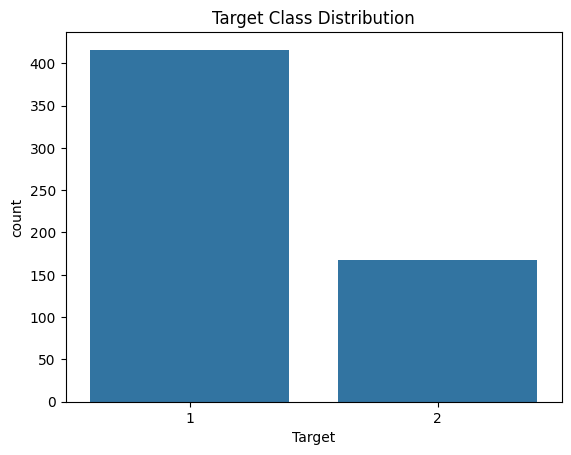

In [14]:
# Target Variable Distribution
sns.countplot(x="Target", data=df)
plt.title("Target Class Distribution")
plt.show()


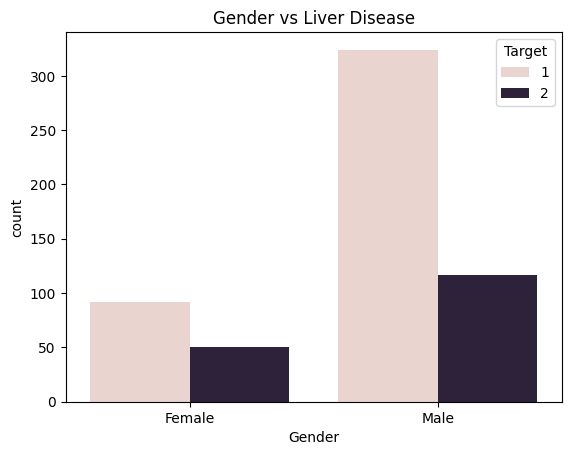

In [15]:
# Gender vs Liver Disease
sns.countplot(x="Gender", hue="Target", data=df)
plt.title("Gender vs Liver Disease")
plt.show()


<function matplotlib.pyplot.show(close=None, block=None)>

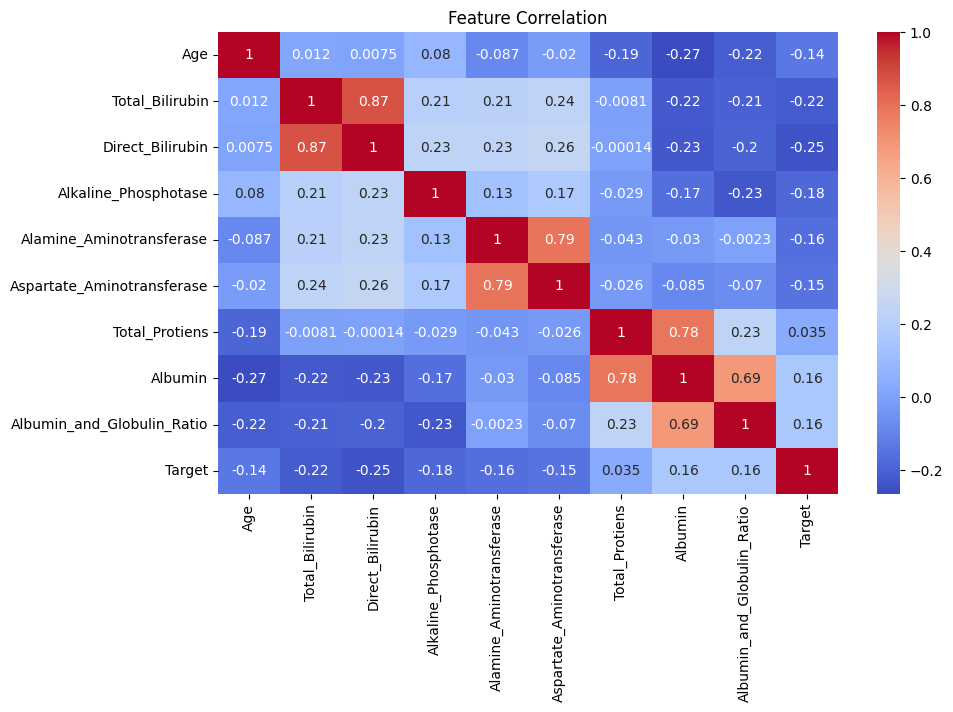

In [16]:
# Correlation Heatmap
plt.figure(figsize=(10,6))
numeric_df = df.select_dtypes(include=np.number)
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm')
plt.title("Feature Correlation")
plt.show

## Data Preprocessing

In [17]:
# Encode Gender
le = LabelEncoder()
df['Gender'] = le.fit_transform(df['Gender'])
le

LabelEncoder()

In [18]:
# Split Features & Target
X = df.drop("Target", axis=1)
y = df["Target"]

In [19]:
X

,Age,Gender,Total_Bilirubin,Direct_Bilirubin,Alkaline_Phosphotase,Alamine_Aminotransferase,Aspartate_Aminotransferase,Total_Protiens,Albumin,Albumin_and_Globulin_Ratio
0,65,0,0.7,0.1,187,16,18,6.8,3.3,0.90
1,62,1,10.9,5.5,699,64,100,7.5,3.2,0.74
2,62,1,7.3,4.1,490,60,68,7.0,3.3,0.89
3,58,1,1.0,0.4,182,14,20,6.8,3.4,1.00
4,72,1,3.9,2.0,195,27,59,7.3,2.4,0.40
...,...,...,...,...,...,...,...,...,...,...
578,60,1,0.5,0.1,500,20,34,5.9,1.6,0.37
579,40,1,0.6,0.1,98,35,31,6.0,3.2,1.10
580,52,1,0.8,0.2,245,48,49,6.4,3.2,1.00
581,31,1,1.3,0.5,184,29,32,6.8,3.4,1.00


In [20]:
y

0      1
1      1
2      1
3      1
4      1
      ..
578    2
579    1
580    1
581    1
582    2
Name: Target, Length: 583, dtype: int64

In [21]:
# Train–Test Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((437, 10), (146, 10), (437,), (146,))

### Feature Scaling

In [22]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)
scaler

StandardScaler()

In [23]:
X_train.shape

(437, 10)

In [24]:
X_test.shape

(146, 10)

## Model Building & Evaluation

### Logistic Regression

In [25]:
lr = LogisticRegression(max_iter=1000)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
lr

LogisticRegression(max_iter=1000)

In [26]:
print("Accuracy:", accuracy_score(y_test, y_pred_lr))
print(confusion_matrix(y_test, y_pred_lr))
print(classification_report(y_test, y_pred_lr))

Accuracy: 0.6986301369863014
[[92 12]
 [32 10]]
              precision    recall  f1-score   support

           1       0.74      0.88      0.81       104
           2       0.45      0.24      0.31        42

    accuracy                           0.70       146
   macro avg       0.60      0.56      0.56       146
weighted avg       0.66      0.70      0.66       146



### Decision Tree

In [27]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train, y_train)
y_pred_dt = dt.predict(X_test)
dt

DecisionTreeClassifier(random_state=42)

In [28]:
print("Accuracy:", accuracy_score(y_test, y_pred_dt))

Accuracy: 0.6506849315068494


### Random Forest

In [29]:
rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
rf

RandomForestClassifier(n_estimators=200, random_state=42)

In [30]:
print("Accuracy:", accuracy_score(y_test, y_pred_rf))

Accuracy: 0.6438356164383562


### Naive Bayes

In [31]:
nb = GaussianNB()
nb.fit(X_train, y_train)
y_pred_nb = nb.predict(X_test)
nb

GaussianNB()

In [32]:
print("Accuracy:", accuracy_score(y_test, y_pred_nb))

Accuracy: 0.5342465753424658


### Support Vector Machine (SVM)

In [33]:
svm = SVC(kernel='rbf')
svm.fit(X_train, y_train)
y_pred_svm = svm.predict(X_test)
svm

SVC()

In [34]:
print("Accuracy:", accuracy_score(y_test, y_pred_svm))

Accuracy: 0.6986301369863014


In [35]:
model_scores = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest', 'Naive Bayes', 'SVM'],
    'Accuracy': [
        accuracy_score(y_test, y_pred_lr),
        accuracy_score(y_test, y_pred_dt),
        accuracy_score(y_test, y_pred_rf),
        accuracy_score(y_test, y_pred_nb),
        accuracy_score(y_test, y_pred_svm)
    ]
})

model_scores


,Model,Accuracy
0,Logistic Regression,0.698630
1,Decision Tree,0.650685
2,Random Forest,0.643836
3,Naive Bayes,0.534247
4,SVM,0.698630


In [36]:
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC()
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    preds = model.predict(X_test)
    results[name] = accuracy_score(y_test, preds)

results_df = pd.DataFrame.from_dict(
    results, orient="index", columns=["Accuracy"]
)

results_df


,Accuracy
Logistic Regression,0.698630
Decision Tree,0.650685
Random Forest,0.643836
Naive Bayes,0.534247
SVM,0.698630


# Model Comparison Report
---
## Objective
* To evaluate and compare the performance of multiple machine learning classification models on the Indian Liver Patient Dataset (ILPD) and recommend the most suitable model for production deployment.

---

## Models Implemented
* The following classification models were trained and tested using the same preprocessing steps:
* 1.Logistic Regression
* 2.Decision Tree Classifier
* 3.Random Forest Classifier
* 4.Naive Bayes
* 5.Support Vector Machine (SVM)

---

### Performance Metric
* Accuracy was used as the evaluation metric.
* A common train–test split and identical preprocessing were applied to all models for fair comparison.

### Model Performance Results (Actual Output)
| Model               | Accuracy   |
| ------------------- | ---------- |
| Logistic Regression | **0.6986** |
| Decision Tree       | 0.6507     |
| Random Forest       | 0.6438     |
| Naive Bayes         | 0.5342     |
| SVM                 | **0.6986** |


* (Actual values may slightly vary depending on random state)

---

### Analysis of Model Performance
* Logistic Regression achieved the highest accuracy along with SVM, indicating that linear relationships play a significant role in this dataset.
* SVM also performed equally well, benefiting from feature scaling and margin maximization.
* Decision Tree and Random Forest showed comparatively lower accuracy, possibly due to limited dataset size and noise.
* Naive Bayes performed the worst because its assumption of feature independence is not valid for biochemical medical data.

---

### Best Model for Production
* Logistic Regression (Recommended)
* Justification:
* Achieved the highest accuracy (0.6986) equal to SVM
* Simpler and more interpretable than SVM
* Faster training and prediction time
* Suitable for healthcare applications where explainability is important
* Hence, Logistic Regression is selected as the best model for production deployment.

---


# Report on Challenges Faced and Techniques Used
---
## 1. Missing Values in Dataset
**Challenge:**
* The column Albumin and Globulin Ratio contained missing values which caused errors during model training.
  
**Technique Used:**
* Median Imputation

**Reason:**
* Median is robust to outliers and preserves the distribution of medical data.

---

## 2. Handling Categorical Data
**Challenge:**
* The Gender column was categorical (Male/Female), which machine learning algorithms cannot process directly.

**Technique Used:**
* Label Encoding

**Reason:**
* Label Encoding converts categorical variables into numerical form suitable for model training.

---

## 3. Correlation Analysis Error
**Challenge:**
* Correlation heatmap generation failed due to the presence of categorical values.

**Technique Used:**
* Correlation was computed only on numerical features.

**Reason:**
* Correlation analysis requires numeric data to measure linear relationships.

---

## 4. Class Imbalance in Target Variable
**Challenge:**
* The dataset contained more liver disease patients than non-liver patients, leading to class imbalance.

**Technique Used:**
* Stratified Train-Test Split

**Reason:**
* Ensures equal class distribution in both training and testing sets.

---

## 5. Class Imbalance in Target Variable
**Challenge:**
* The dataset contained more liver disease patients than non-liver patients, leading to class imbalance.

**Technique Used:**
* Stratified Train-Test Split

**Reason:**
* Ensures equal class distribution in both training and testing sets.

---

## 6. Model Performance Variation
**Challenge:**
* Complex models like Random Forest did not perform as expected.

**Technique Used:**
* Model comparison and evaluation

**Reason:**
* Simple models generalized better due to limited dataset size and noise.

---

## Summary of Challenges and Solutions
| Challenge           | Technique Used           | Justification            |
| ------------------- | ------------------------ | ------------------------ |
| Missing values      | Median Imputation        | Robust to outliers       |
| Categorical data    | Label Encoding           | Numeric conversion       |
| Correlation error   | Numeric-only correlation | Required for correlation |
| Class imbalance     | Stratified split         | Fair evaluation          |
| Feature scale issue | StandardScaler           | Improves accuracy        |
| Model selection     | Model comparison         | Best generalization      |

---

# Final Conclusion
Multiple machine learning models were implemented and evaluated on the Indian Liver Patient Dataset. Based on the obtained results, Logistic Regression achieved the highest accuracy and demonstrated stable and interpretable performance. Therefore, it is recommended as the best model for liver disease prediction in this study.